In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

from google.colab import drive
drive.mount('/content/drive')

RAW_PATH = '/content/drive/MyDrive/Sales_Automation/Data/Raw/spro_sample.csv'

df_raw = pd.read_csv(RAW_PATH)

print(f'✅ Data loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
print(f'Columns: {list(df_raw.columns)}')

Libraries loaded
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data loaded: 5000 rows, 22 columns
Columns: ['Date', 'SR ID', 'Route Name', 'Shop Name', 'Visit Start', 'Visit End', 'GPS Status', 'Product Category', 'SKU Name', 'Qty (Pcs)', 'Unit Price', 'Total Val', 'Stock in Shop', 'Order Status', 'Payment Mode', 'Shop ID', 'Order ID', 'Distributor Name', 'Latitude', 'Longitude', 'Return Order', 'SR Daily Target']


In [3]:
print('=== FIRST 3 ROWS ===')
display(df_raw.head(3))

print('\n=== DATA TYPES ===')
print(df_raw.dtypes)

print('\n=== MISSING VALUES ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values')

print(f'\nShape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')

=== FIRST 3 ROWS ===


,Date,SR ID,Route Name,Shop Name,Visit Start,Visit End,GPS Status,Product Category,SKU Name,Qty (Pcs),...,Stock in Shop,Order Status,Payment Mode,Shop ID,Order ID,Distributor Name,Latitude,Longitude,Return Order,SR Daily Target
0,20-Mar-26,SR-101,Uttara-10,Brothers Store,09:11:48,09:22:17,Matched,Furniture,RFL Plastic Table,5,...,27,Confirmed,Credit,SHOP-1394,ORD-664102,Dhaka South Depot,23.8738,90.3984,No,60000
1,09-Mar-26,SR-53,Mohammadpur,Hasan Traders,13:25:53,13:34:56,Matched,Kitchenware,RFL Spice Box,17,...,43,Cancelled,bKash,SHOP-5165,ORD-310258,Narayanganj Hub,23.7570,90.3580,No,30000
2,28-Mar-26,SR-146,Uttara-3,Hasan Traders,16:09:13,16:23:17,Weak,Plastics,RFL Plastic Chair,2,...,40,Pending,Nagad,SHOP-8606,ORD-342753,Dhaka South Depot,23.8759,90.3795,No,60000



=== DATA TYPES ===
Date                 object
SR ID                object
Route Name           object
Shop Name            object
Visit Start          object
Visit End            object
GPS Status           object
Product Category     object
SKU Name             object
Qty (Pcs)             int64
Unit Price            int64
Total Val             int64
Stock in Shop         int64
Order Status         object
Payment Mode         object
Shop ID              object
Order ID             object
Distributor Name     object
Latitude            float64
Longitude           float64
Return Order         object
SR Daily Target       int64
dtype: object

=== MISSING VALUES ===
No missing values

Shape: 5000 rows × 22 columns


In [4]:
df = df_raw.copy()

# Parse date
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y', errors='coerce')

invalid_dates = df['Date'].isnull().sum()
print(f'Invalid dates found: {invalid_dates}')

# Extract useful columns from date
df['Month']     = df['Date'].dt.strftime('%b-%Y')
df['Day']       = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()

print('Date columns created: Month, Day, DayOfWeek')
display(df[['Date', 'Month', 'Day', 'DayOfWeek']].head(3))


def calc_duration(start, end):
    try:
        fmt = '%H:%M:%S'
        s = datetime.strptime(start, fmt)
        e = datetime.strptime(end, fmt)
        duration = (e - s).seconds / 60
        return round(duration, 2) if duration > 0 else np.nan
    except:
        return np.nan

df['Visit Duration (min)'] = df.apply(
    lambda row: calc_duration(str(row['Visit Start']), str(row['Visit End'])),
    axis=1
)

avg = df['Visit Duration (min)'].mean()
print(f'Visit Duration calculated')
print(f'   Average visit duration: {avg:.1f} minutes')
print(f'   Min: {df["Visit Duration (min)"].min():.1f} min')
print(f'   Max: {df["Visit Duration (min)"].max():.1f} min')

Invalid dates found: 0
Date columns created: Month, Day, DayOfWeek


,Date,Month,Day,DayOfWeek
0,2026-03-20,Mar-2026,20,Friday
1,2026-03-09,Mar-2026,9,Monday
2,2026-03-28,Mar-2026,28,Saturday


Visit Duration calculated
   Average visit duration: 15.5 minutes
   Min: 5.0 min
   Max: 26.0 min


In [5]:
df['Expected Val'] = df['Qty (Pcs)'] * df['Unit Price']
df['Val Mismatch'] = ~np.isclose(df['Total Val'], df['Expected Val'], rtol=0.01)

mismatches = df['Val Mismatch'].sum()
print(f'🔍 Value mismatches found: {mismatches}')

if mismatches > 0:
    print('\nSample mismatched rows:')
    display(df[df['Val Mismatch']][
        ['Order ID', 'SKU Name', 'Qty (Pcs)', 'Unit Price', 'Total Val', 'Expected Val']
    ].head(5))
else:
    print('All values are correct')


before = df.shape[0]
df = df.drop_duplicates(subset='Order ID', keep='first')
removed = before - df.shape[0]

print(f'Duplicates removed: {removed}')
print(f'✅ Rows remaining: {df.shape[0]}')


🔍 Value mismatches found: 0
All values are correct
Duplicates removed: 9
✅ Rows remaining: 4991


In [6]:
text_cols = [
    'SR ID', 'Route Name', 'Shop Name', 'GPS Status',
    'Product Category', 'SKU Name', 'Order Status', 'Payment Mode'
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print('Text columns standardized')
print('\nUnique GPS Status values:', df['GPS Status'].unique())
print('Unique Order Status values:', df['Order Status'].unique())
print('Unique Payment Mode values:', df['Payment Mode'].unique())

def quality_flag(row):
    if pd.isnull(row['Date']):
        return 'Invalid Date'
    if pd.isnull(row['Visit Duration (min)']):
        return 'Missing Duration'
    if row['Val Mismatch']:
        return 'Value Mismatch'
    if row['GPS Status'] == 'Not Matched':
        return 'GPS Issue'
    return 'Clean'

df['Data Quality Flag'] = df.apply(quality_flag, axis=1)

print('Data Quality Flags:')
print(df['Data Quality Flag'].value_counts().to_string())

Text columns standardized

Unique GPS Status values: ['Matched' 'Weak' 'Not Matched']
Unique Order Status values: ['Confirmed' 'Cancelled' 'Pending']
Unique Payment Mode values: ['Credit' 'Bkash' 'Nagad' 'Cash']
Data Quality Flags:
Data Quality Flag
Clean        4553
GPS Issue     438


In [7]:
clean_count   = (df['Data Quality Flag'] == 'Clean').sum()
suspect_count = (df['Data Quality Flag'] != 'Clean').sum()
clean_pct     = round(clean_count / df.shape[0] * 100, 1)

print('=' * 45)
print('DATA CLEANING SUMMARY REPORT')
print('=' * 45)
print(f'  Total Raw Rows      : {df_raw.shape[0]:,}')
print(f'  After Dedup         : {df.shape[0]:,}')
print(f'  Clean Records       : {clean_count:,}  ({clean_pct}%)')
print(f'  Flagged Records     : {suspect_count:,}')
print(f'  Avg Visit Duration  : {df["Visit Duration (min)"].mean():.1f} min')
print(f'  Date Range          : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'  Unique SRs          : {df["SR ID"].nunique()}')
print(f'  Unique Routes       : {df["Route Name"].nunique()}')
print(f'  Unique Shops        : {df["Shop Name"].nunique()}')
print('=' * 45)
print('Cleaning done. Ready for KPI generation.')

DATA CLEANING SUMMARY REPORT
  Total Raw Rows      : 5,000
  After Dedup         : 4,991
  Clean Records       : 4,553  (91.2%)
  Flagged Records     : 438
  Avg Visit Duration  : 15.5 min
  Date Range          : 2026-03-01 → 2026-03-31
  Unique SRs          : 150
  Unique Routes       : 10
  Unique Shops        : 15
Cleaning done. Ready for KPI generation.


In [10]:
# Drop helper columns before saving
df_clean = df.drop(columns=['Expected Val', 'Val Mismatch'])

CLEAN_PATH = '/content/drive/MyDrive/Sales_Automation/Data/processed/cleaned_data.csv'

df_clean.to_csv(CLEAN_PATH, index=False)

print(f'Cleaned data saved to Google Drive')
print(f'   Rows: {df_clean.shape[0]:,}')
print(f'   Columns: {df_clean.shape[1]}')

Cleaned data saved to Google Drive
   Rows: 4,991
   Columns: 27


In [11]:
import json

CLEAN_PATH = '/content/drive/MyDrive/Sales_Automation/Data/processed/cleaned_data.csv'

df = pd.read_csv(CLEAN_PATH, parse_dates=['Date'])

print(f'Cleaned data loaded: {df.shape[0]:,} rows')
display(df.head(3))

Cleaned data loaded: 4,991 rows


,Date,SR ID,Route Name,Shop Name,Visit Start,Visit End,GPS Status,Product Category,SKU Name,Qty (Pcs),...,Distributor Name,Latitude,Longitude,Return Order,SR Daily Target,Month,Day,DayOfWeek,Visit Duration (min),Data Quality Flag
0,2026-03-20,Sr-101,Uttara-10,Brothers Store,09:11:48,09:22:17,Matched,Furniture,Rfl Plastic Table,5,...,Dhaka South Depot,23.8738,90.3984,No,60000,Mar-2026,20,Friday,10.48,Clean
1,2026-03-09,Sr-53,Mohammadpur,Hasan Traders,13:25:53,13:34:56,Matched,Kitchenware,Rfl Spice Box,17,...,Narayanganj Hub,23.7570,90.3580,No,30000,Mar-2026,9,Monday,9.05,Clean
2,2026-03-28,Sr-146,Uttara-3,Hasan Traders,16:09:13,16:23:17,Weak,Plastics,Rfl Plastic Chair,2,...,Dhaka South Depot,23.8759,90.3795,No,60000,Mar-2026,28,Saturday,14.07,Clean


In [14]:
total_sales      = df['Total Val'].sum()
total_orders     = df.shape[0]
active_srs       = df['SR ID'].nunique()
shops_visited    = df['Shop ID'].nunique()       # fixed: use Shop ID not Shop Name
avg_visit_dur    = round(df['Visit Duration (min)'].mean(), 1)
confirmed_orders = (df['Order Status'] == 'Confirmed').sum()
confirmation_rate = round(confirmed_orders / total_orders * 100, 1)

# ── Fix Target Calculation ──────────────────────────────────
# Each SR has one fixed daily target. We want: sum of all SR targets × working days

# Step 1: get each SR's daily target (use median to avoid outliers)
sr_daily_targets = df.groupby('SR ID')['SR Daily Target'].median()

# Step 2: count actual working days in the dataset
working_days = df['Date'].nunique()

# Step 3: total target = sum of all SR daily targets × working days
total_target = sr_daily_targets.sum() * working_days

achievement_pct = round(total_sales / total_target * 100, 1) if total_target else 0

print('=' * 48)
print(' TOP-LEVEL KPI SUMMARY')
print('=' * 48)
print(f'  Total Sales (BDT)         : ৳{total_sales:>15,.0f}')
print(f'  Total Orders              : {total_orders:>15,}')
print(f'  Total Target (BDT)        : ৳{total_target:>15,.0f}')
print(f'  Target Achievement        : {achievement_pct:>14}%')
print(f'  Active SRs                : {active_srs:>15}')
print(f'  Shops Visited             : {shops_visited:>15}')
print(f'  Working Days in Data      : {working_days:>15}')
print(f'  Avg Visit Duration        : {avg_visit_dur:>13} min')
print(f'  Order Confirmation Rate   : {confirmation_rate:>14}%')
print('=' * 48)


 TOP-LEVEL KPI SUMMARY
  Total Sales (BDT)         : ৳    202,268,682
  Total Orders              :           4,991
  Total Target (BDT)        : ৳    211,575,000
  Target Achievement        :           95.6%
  Active SRs                :             150
  Shops Visited             :            3847
  Working Days in Data      :              31
  Avg Visit Duration        :          15.5 min
  Order Confirmation Rate   :           59.8%


In [16]:
# Sales by route
sales_by_route = (
    df.groupby('Route Name')['Total Val']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Total Val': 'Total Sales (BDT)'})
)

sales_by_route['% of Total'] = round(
    sales_by_route['Total Sales (BDT)'] / total_sales * 100, 1
)
sales_by_route['Total Sales (BDT)'] = sales_by_route['Total Sales (BDT)'].round(0).astype(int)

print('Sales by Route (Top 10):')
display(sales_by_route.head(10))

Sales by Route (Top 10):


,Route Name,Total Sales (BDT),% of Total
0,Dhanmondi,21875918,10.8
1,Mirpur-1,21294838,10.5
2,Savar,21265472,10.5
3,Uttara-3,20629326,10.2
4,Mirpur-10,20074547,9.9
5,Gazipur,19992899,9.9
6,Narayanganj,19866872,9.8
7,Chittagong,19698807,9.7
8,Uttara-10,19548154,9.7
9,Mohammadpur,18021849,8.9


In [18]:
# Sales By Product Category  & Top SKUs
sales_by_cat = (
    df.groupby('Product Category')['Total Val']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Total Val': 'Total Sales (BDT)'})
)
sales_by_cat['% of Total'] = round(
    sales_by_cat['Total Sales (BDT)'] / total_sales * 100, 1
)
sales_by_cat['Total Sales (BDT)'] = sales_by_cat['Total Sales (BDT)'].round(0).astype(int)

print('Sales by Product Category:')
display(sales_by_cat)

# Top 10 SKUs
top_skus = (
    df.groupby('SKU Name')['Total Val']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'Total Val': 'Total Sales (BDT)'})
)
top_skus['Total Sales (BDT)'] = top_skus['Total Sales (BDT)'].round(0).astype(int)

print('Top 10 Products by Sales:')
display(top_skus)

Sales by Product Category:


,Product Category,Total Sales (BDT),% of Total
0,Electronics,42771552,21.1
1,Kitchenware,41743821,20.6
2,Household,40216262,19.9
3,Plastics,39861390,19.7
4,Furniture,37675657,18.6


Top 10 Products by Sales:


,SKU Name,Total Sales (BDT)
0,Vision Led Tv 43,14923469
1,Vision Led Tv 32,14515901
2,Rfl Food Carrier,14333543
3,Rfl Mop Set,14195415
4,Rfl Rice Container,13760876
5,Rfl Spice Box,13649402
6,Vision Fan,13332182
7,Rfl Laundry Basket,13294821
8,Rfl Dustbin,12726026
9,Rfl Wardrobe,12713891


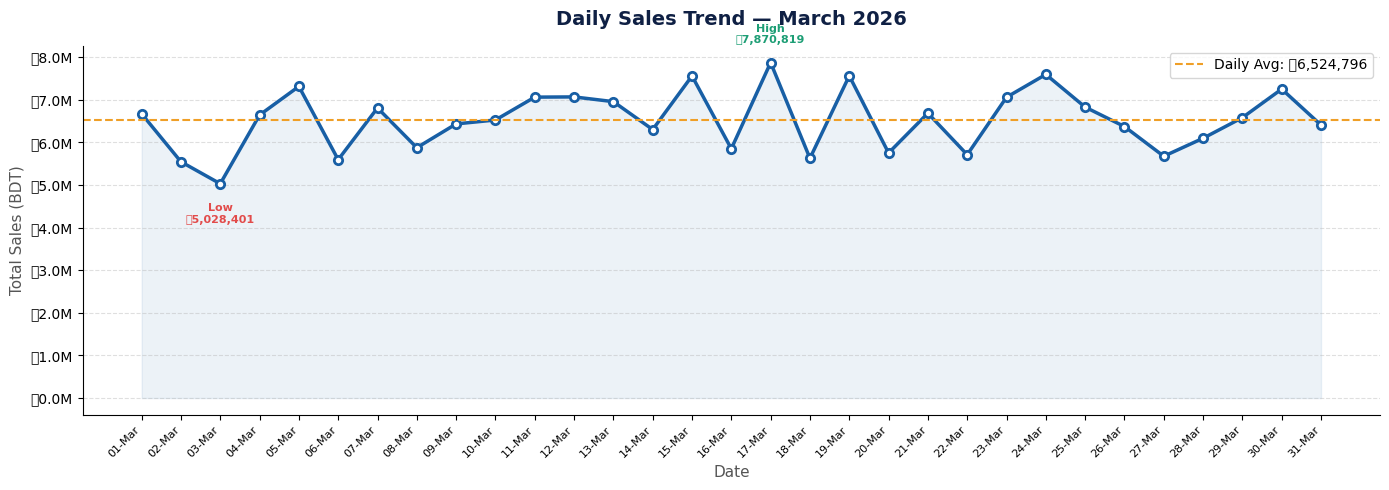


Daily Trend Summary:
  Highest Day : 17-Mar — ৳7,870,819
  Lowest Day  : 03-Mar — ৳5,028,401
  Daily Avg   : ৳6,524,796
  Total Days  : 31

Chart saved to Google Drive → output/daily_sales_trend.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

daily_trend = (
    df.groupby('Date')['Total Val']
    .sum()
    .reset_index()
    .rename(columns={'Total Val': 'Daily Sales (BDT)'})
    .sort_values('Date')
)

daily_trend['Date Label']        = daily_trend['Date'].dt.strftime('%d-%b')
daily_trend['Daily Sales (BDT)'] = daily_trend['Daily Sales (BDT)'].round(0).astype(int)

#  Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    daily_trend['Date Label'],
    daily_trend['Daily Sales (BDT)'],
    color='#185fa5', linewidth=2.5, marker='o',
    markersize=6, markerfacecolor='white', markeredgewidth=2
)

# Shade area under line
ax.fill_between(
    daily_trend['Date Label'],
    daily_trend['Daily Sales (BDT)'],
    alpha=0.08, color='#185fa5'
)

# Average line
avg_sales = daily_trend['Daily Sales (BDT)'].mean()
ax.axhline(avg_sales, color='#ef9f27', linewidth=1.5,
           linestyle='--', label=f'Daily Avg: ৳{avg_sales:,.0f}')

# Highlight highest & lowest day
max_idx = daily_trend['Daily Sales (BDT)'].idxmax()
min_idx = daily_trend['Daily Sales (BDT)'].idxmin()

ax.annotate(
    f"High\n৳{daily_trend.loc[max_idx, 'Daily Sales (BDT)']:,.0f}",
    xy=(daily_trend.loc[max_idx, 'Date Label'], daily_trend.loc[max_idx, 'Daily Sales (BDT)']),
    xytext=(0, 14), textcoords='offset points',
    ha='center', fontsize=8, color='#1d9e75', fontweight='bold'
)

ax.annotate(
    f"Low\n৳{daily_trend.loc[min_idx, 'Daily Sales (BDT)']:,.0f}",
    xy=(daily_trend.loc[min_idx, 'Date Label'], daily_trend.loc[min_idx, 'Daily Sales (BDT)']),
    xytext=(0, -28), textcoords='offset points',
    ha='center', fontsize=8, color='#e24b4a', fontweight='bold'
)

# Formatting
ax.set_title('Daily Sales Trend — March 2026', fontsize=14,
             fontweight='bold', pad=15, color='#0f2044')
ax.set_xlabel('Date', fontsize=11, color='#555')
ax.set_ylabel('Total Sales (BDT)', fontsize=11, color='#555')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'৳{x/1_000_000:.1f}M'
))
ax.set_xticks(range(len(daily_trend)))
ax.set_xticklabels(daily_trend['Date Label'], rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Sales_Automation/output/daily_sales_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDaily Trend Summary:')
print(f'  Highest Day : {daily_trend.loc[max_idx, "Date Label"]} — ৳{daily_trend.loc[max_idx, "Daily Sales (BDT)"]:,.0f}')
print(f'  Lowest Day  : {daily_trend.loc[min_idx, "Date Label"]} — ৳{daily_trend.loc[min_idx, "Daily Sales (BDT)"]:,.0f}')
print(f'  Daily Avg   : ৳{avg_sales:,.0f}')
print(f'  Total Days  : {len(daily_trend)}')
print(f'\nChart saved to Google Drive → output/daily_sales_trend.png')

In [22]:
# SR Performance Table
sr_perf = df.groupby('SR ID').agg(
    Total_Sales   = ('Total Val',        'sum'),
    Total_Orders  = ('Order ID',         'count'),
    Daily_Target  = ('SR Daily Target',  'max'),
    Avg_Duration  = ('Visit Duration (min)', 'mean'),
    GPS_Issues    = ('GPS Status',       lambda x: (x == 'Not Matched').sum()),
    Cancellations = ('Order Status',     lambda x: (x == 'Cancelled').sum())
).reset_index()

sr_perf['Monthly Target']     = sr_perf['Daily_Target'] * 30
sr_perf['Achievement (%)']    = round(sr_perf['Total_Sales'] / sr_perf['Monthly Target'] * 100, 1)
sr_perf['Cancel Rate (%)']    = round(sr_perf['Cancellations'] / sr_perf['Total_Orders'] * 100, 1)
sr_perf['GPS Mismatch (%)']   = round(sr_perf['GPS_Issues'] / sr_perf['Total_Orders'] * 100, 1)
sr_perf['Avg Duration (min)'] = sr_perf['Avg_Duration'].round(1)

def perf_tier(ach):
    if ach >= 90:   return 'On Track'
    elif ach >= 70: return 'Needs Attention'
    else:           return 'Below Target'

sr_perf['Performance Tier'] = sr_perf['Achievement (%)'].apply(perf_tier)

sr_display = sr_perf[[
    'SR ID', 'Total_Sales', 'Monthly Target',
    'Achievement (%)', 'Cancel Rate (%)',
    'GPS Mismatch (%)', 'Performance Tier'
]].sort_values('Achievement (%)', ascending=False)

print('SR Performance Table:')
print(f'  On Track       : {(sr_perf["Performance Tier"] == "On Track").sum()} SRs')
print(f'  Needs Attention: {(sr_perf["Performance Tier"] == "Needs Attention").sum()} SRs')
print(f'  Below Target   : {(sr_perf["Performance Tier"] == "Below Target").sum()} SRs')
print()
display(sr_display.head(10))

SR Performance Table:
  On Track       : 28 SRs
  Needs Attention: 66 SRs
  Below Target   : 56 SRs



,SR ID,Total_Sales,Monthly Target,Achievement (%),Cancel Rate (%),GPS Mismatch (%),Performance Tier
98,Sr-52,2124950,1800000,118.1,23.4,2.1,On Track
113,Sr-66,2065870,1800000,114.8,19.0,4.8,On Track
51,Sr-145,2049711,1800000,113.9,15.8,13.2,On Track
30,Sr-126,2018992,1800000,112.2,20.5,9.1,On Track
9,Sr-107,2004593,1800000,111.4,18.0,2.0,On Track
96,Sr-50,1996663,1800000,110.9,14.6,9.8,On Track
58,Sr-16,1966721,1800000,109.3,22.2,6.7,On Track
145,Sr-95,1922043,1800000,106.8,13.6,9.1,On Track
63,Sr-20,1920966,1800000,106.7,16.3,7.0,On Track
43,Sr-138,1912529,1800000,106.3,20.5,12.8,On Track


In [23]:
# Payment Mode
payment_breakdown = (
    df.groupby('Payment Mode')['Total Val']
    .sum()
    .reset_index()
    .rename(columns={'Total Val': 'Total Sales (BDT)'})
    .sort_values('Total Sales (BDT)', ascending=False)
)
payment_breakdown['%'] = round(
    payment_breakdown['Total Sales (BDT)'] / total_sales * 100, 1
)

# Order Status
order_status = (
    df['Order Status']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'Count'})
)
order_status['%'] = round(order_status['Count'] / total_orders * 100, 1)

# GPS Compliance
gps_compliance = (
    df['GPS Status']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'Count'})
)
gps_compliance['%'] = round(gps_compliance['Count'] / total_orders * 100, 1)

print('Payment Mode:')
display(payment_breakdown)
print('\nOrder Status:')
display(order_status)
print('\nGPS Compliance:')
display(gps_compliance)

Payment Mode:


,Payment Mode,Total Sales (BDT),%
3,Nagad,53441892,26.4
2,Credit,52713491,26.1
0,Bkash,48118298,23.8
1,Cash,47995001,23.7



Order Status:


,Order Status,Count,%
0,Confirmed,2983,59.8
1,Pending,1170,23.4
2,Cancelled,838,16.8



GPS Compliance:


,GPS Status,Count,%
0,Matched,3946,79.1
1,Weak,607,12.2
2,Not Matched,438,8.8


In [24]:
LOW_STOCK_THRESHOLD = 5

low_stock = (
    df[df['Stock in Shop'] < LOW_STOCK_THRESHOLD]
    [['Shop Name', 'Route Name', 'SKU Name', 'Stock in Shop', 'Date']]
    .sort_values('Stock in Shop')
    .drop_duplicates(subset=['Shop Name', 'SKU Name'])
    .reset_index(drop=True)
)

low_stock['Alert Level'] = low_stock['Stock in Shop'].apply(
    lambda x: 'Critical' if x == 0 else 'Low'
)

print(f'Low Stock Alerts: {len(low_stock)} shop-product combinations')
display(low_stock.head(10))

Low Stock Alerts: 193 shop-product combinations


,Shop Name,Route Name,SKU Name,Stock in Shop,Date,Alert Level
0,Azad Store,Uttara-3,Rfl Food Carrier,0,2026-03-10,Critical
1,New Market Traders,Chittagong,Vision Fan,0,2026-03-29,Critical
2,Green Valley Shop,Mirpur-10,Rfl Food Carrier,0,2026-03-15,Critical
3,New Market Traders,Gazipur,Rfl Food Carrier,0,2026-03-13,Critical
4,New Market Traders,Savar,Rfl Laundry Basket,0,2026-03-05,Critical
5,Hasan Traders,Mirpur-1,Rfl Rice Container,0,2026-03-18,Critical
6,Karim Store,Savar,Rfl Storage Box,0,2026-03-21,Critical
7,Maa Enterprise,Uttara-10,Rfl Wardrobe,0,2026-03-28,Critical
8,Hasan Traders,Mirpur-1,Rfl Water Jug,0,2026-03-21,Critical
9,Sadia Store,Dhanmondi,Rfl Spice Box,0,2026-03-13,Critical


In [27]:
kpi_package = {
    'summary': {
        'Total Sales (BDT)':               total_sales,
        'Total Orders':                    total_orders,
        'Shops Visited':                   int(shops_visited),
        'Active SRs':                      int(active_srs),
        'Total Target (BDT)':              total_target,
        'Target Achievement (%)':          achievement_pct,
        'Avg Visit Duration (min)':        avg_visit_dur,
        'Order Confirmation Rate (%)':     confirmation_rate
    },
    'sales_by_route':    sales_by_route.head(10).to_dict(orient='records'),
    'sales_by_cat':      sales_by_cat.to_dict(orient='records'),
    'top_skus':          top_skus.to_dict(orient='records'),
    'daily_trend':       daily_trend[['Date Label', 'Daily Sales (BDT)']].to_dict(orient='records'),
    'sr_performance':    sr_display.head(20).to_dict(orient='records'),
    'payment_breakdown': payment_breakdown.to_dict(orient='records'),
    'order_status':      order_status.to_dict(orient='records'),
    'gps_compliance':    gps_compliance.to_dict(orient='records'),
    'low_stock':         low_stock.to_dict(orient='records')
}

KPI_PATH = '/content/drive/MyDrive/Sales_Automation/Data/processed/kpi_output.json'

with open(KPI_PATH, 'w') as f:
    json.dump(kpi_package, f, indent=2, default=str)

print('All KPIs saved to kpi_output.json')
print(f'   Sections saved: {list(kpi_package.keys())}')

All KPIs saved to kpi_output.json
   Sections saved: ['summary', 'sales_by_route', 'sales_by_cat', 'top_skus', 'daily_trend', 'sr_performance', 'payment_breakdown', 'order_status', 'gps_compliance', 'low_stock']


In [28]:
!pip install gspread gspread-formatting --quiet

import gspread
from gspread_formatting import *
from google.colab import auth, drive
from google.auth import default

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
drive.mount('/content/drive')

print('Authenticated and ready')


KPI_PATH = '/content/drive/MyDrive/Sales_Automation/Data/processed/kpi_output.json'

with open(KPI_PATH, 'r') as f:
    kpis = json.load(f)

summary  = kpis['summary']
by_route = pd.DataFrame(kpis['sales_by_route'])
by_cat   = pd.DataFrame(kpis['sales_by_cat'])
top_skus = pd.DataFrame(kpis['top_skus'])
daily    = pd.DataFrame(kpis['daily_trend'])
sr_perf  = pd.DataFrame(kpis['sr_performance'])
payment  = pd.DataFrame(kpis['payment_breakdown'])
order_st = pd.DataFrame(kpis['order_status'])
gps      = pd.DataFrame(kpis['gps_compliance'])
low_stock= pd.DataFrame(kpis['low_stock'])

print('KPI data loaded')
print(f'   Sections: {list(kpis.keys())}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Authenticated and ready
KPI data loaded
   Sections: ['summary', 'sales_by_route', 'sales_by_cat', 'top_skus', 'daily_trend', 'sr_performance', 'payment_breakdown', 'order_status', 'gps_compliance', 'low_stock']


In [29]:
SHEET_NAME = 'Sales Automation Report'

try:
    sh = gc.open(SHEET_NAME)
    print(f'Opened existing sheet: {SHEET_NAME}')
except gspread.SpreadsheetNotFound:
    sh = gc.create(SHEET_NAME)
    print(f'Created new sheet: {SHEET_NAME}')

print(f'\n Your Sheet URL:')
print(f'   {sh.url}')
print('\n Copy this URL — you will share it with the recruiter!')

Created new sheet: Sales Automation Report

 Your Sheet URL:
   https://docs.google.com/spreadsheets/d/1czkaf4Dg-ey-phXdUHHJiPoyYTAU2QNxj_MoUGVxnsM

 Copy this URL — you will share it with the recruiter!


In [30]:
def make_fmt(hex_color, bold=True, font_size=10, text_color='white'):
    r, g, b = [int(hex_color[i:i+2], 16)/255 for i in (1, 3, 5)]
    tc = Color(1, 1, 1) if text_color == 'white' else Color(0, 0, 0)
    return CellFormat(
        backgroundColor=Color(r, g, b),
        textFormat=TextFormat(bold=bold, foregroundColor=tc, fontSize=font_size),
        horizontalAlignment='CENTER'
    )

def write_sheet(sh, tab_name, df_data, header_color='#0f2044'):
    try:
        ws = sh.worksheet(tab_name)
        ws.clear()
    except gspread.WorksheetNotFound:
        ws = sh.add_worksheet(title=tab_name, rows=500, cols=20)

    headers = list(df_data.columns)
    rows    = [[str(v) for v in r] for r in df_data.values.tolist()]

    ws.update([headers] + rows, 'A1')
    format_cell_range(ws, f'A1:{chr(64 + len(headers))}1', make_fmt(header_color))
    ws.freeze(rows=1)
    ws.columns_auto_resize(0, len(headers) - 1)
    return ws

# Color palette
DARK_BLUE = '#0f2044'
MID_BLUE  = '#185fa5'
GREEN     = '#1d9e75'
ORANGE    = '#ef9f27'
RED       = '#e24b4a'

print('Formatting helpers ready')

Formatting helpers ready


In [39]:
from datetime import date

try:
    ws_ex = sh.worksheet('Executive Summary')
    ws_ex.clear()
except gspread.WorksheetNotFound:
    ws_ex = sh.add_worksheet('Executive Summary', rows=50, cols=10)

exec_rows = [
    ['',' Sales Automation Dashboard', '', '', ''],
    ['Generated on:', str(date.today()), '', '', '', ''],
    ['', '', '', '', '', ''],
    ['KPI', 'Value', '', 'KPI', 'Value', ''],
    ['Total Sales (BDT)',       f"৳{int(summary['Total Sales (BDT)']):,.0f}",      '', 'Active SRs',              summary['Active SRs'],                    ''],
    ['Total Orders',            summary['Total Orders'],                        '', 'Shops Visited',           summary['Shops Visited'],                 ''],
    ['Total Target (BDT)',      f"৳{int(summary['Total Target (BDT)']):,.0f}",      '', 'Avg Visit Duration',      f"{summary['Avg Visit Duration (min)']} min", ''],
    ['Target Achievement (%)',  f"{summary['Target Achievement (%)']}%",       '', 'Confirmation Rate',       f"{summary['Order Confirmation Rate (%)']}%", ''],
]

ws_ex.update(exec_rows, 'A1')

# Title row formatting
format_cell_range(ws_ex, 'A1:F1', CellFormat(
    backgroundColor=Color(*[int(DARK_BLUE[i:i+2], 16)/255 for i in (1, 3, 5)]),
    textFormat=TextFormat(bold=True, foregroundColor=Color(1,1,1), fontSize=14),
    horizontalAlignment='CENTER', verticalAlignment='MIDDLE'
))

# KPI header row
format_cell_range(ws_ex, 'A4:F4', make_fmt(MID_BLUE))

# Bold KPI values
for row_num in ['5', '6', '7', '8']:
    for col in ['B', 'E']:
        format_cell_range(ws_ex, f'{col}{row_num}', CellFormat(
            textFormat=TextFormat(bold=True, fontSize=12),
            horizontalAlignment='CENTER'
        ))

ws_ex.columns_auto_resize(0, 5)
print('Sheet 1 — Executive Summary done')


Sheet 1 — Executive Summary done


In [40]:
ws_route = write_sheet(sh, 'Sales by Route', by_route, MID_BLUE)
print('Sheet 2 — Sales by Route done')


ws_sr = write_sheet(sh, 'SR Performance', sr_perf, DARK_BLUE)

# Color code the Performance Tier column
tier_col = chr(64 + len(sr_perf.columns))
rows_data = [[str(v) for v in r] for r in sr_perf.values.tolist()]

for i, row in enumerate(rows_data, start=2):
    tier = row[-1]
    if 'On Track' in tier:
        bg = Color(*[int(GREEN[i:i+2], 16)/255 for i in (1, 3, 5)])
    elif 'Needs' in tier:
        bg = Color(*[int(ORANGE[i:i+2], 16)/255 for i in (1, 3, 5)])
    else:
        bg = Color(*[int(RED[i:i+2], 16)/255 for i in (1, 3, 5)])

    format_cell_range(ws_sr, f'{tier_col}{i}', CellFormat(
        backgroundColor=bg,
        textFormat=TextFormat(bold=True, foregroundColor=Color(1, 1, 1))
    ))

print('Sheet 3 — SR Performance done with color coding')

Sheet 2 — Sales by Route done
Sheet 3 — SR Performance done with color coding


In [41]:
ws_daily = write_sheet(sh, 'Daily Trend', daily, MID_BLUE)
print('Sheet 4 — Daily Trend done')
print('Tip: Select columns A & B → Insert → Chart → Line chart')


ws_low = write_sheet(sh, 'Low Stock Alerts', low_stock, RED)

# Highlight rows where stock = 0
stock_col_idx    = list(low_stock.columns).index('Stock in Shop')
low_stock_rows   = [[str(v) for v in r] for r in low_stock.values.tolist()]

for i, row in enumerate(low_stock_rows, start=2):
    try:
        if int(float(row[stock_col_idx])) == 0:
            format_cell_range(ws_low, f'A{i}:F{i}', CellFormat(
                backgroundColor=Color(1, 0.85, 0.85),
                textFormat=TextFormat(bold=True)
            ))
    except:
        pass

print('Sheet 5 — Low Stock Alerts done with critical row highlighting')

Sheet 4 — Daily Trend done
Tip: Select columns A & B → Insert → Chart → Line chart
Sheet 5 — Low Stock Alerts done with critical row highlighting


In [42]:
pay_rows = [[str(v) for v in r] for r in payment.values.tolist()]
ord_rows = [[str(v) for v in r] for r in order_st.values.tolist()]
gps_rows = [[str(v) for v in r] for r in gps.values.tolist()]

try:
    ws_ops = sh.worksheet('Operations Breakdown')
    ws_ops.clear()
except gspread.WorksheetNotFound:
    ws_ops = sh.add_worksheet('Operations Breakdown', rows=50, cols=15)

ws_ops.update([['PAYMENT MODE']] + [list(payment.columns)]  + pay_rows, 'A1')
ws_ops.update([['ORDER STATUS']] + [list(order_st.columns)] + ord_rows, 'D1')
ws_ops.update([['GPS COMPLIANCE']] + [list(gps.columns)]    + gps_rows, 'G1')

for col in ['A', 'D', 'G']:
    format_cell_range(ws_ops, f'{col}1', make_fmt(DARK_BLUE, font_size=11))
    format_cell_range(ws_ops, f'{col}2', make_fmt(MID_BLUE))

ws_ops.columns_auto_resize(0, 9)
print('Sheet 6 — Operations Breakdown done')



# Remove default empty Sheet1 if it exists
try:
    sh.del_worksheet(sh.worksheet('Sheet1'))
except:
    pass

print('=' * 50)
print('  GOOGLE SHEETS REPORT COMPLETE!')
print('=' * 50)
print(f'  Tabs created:')
for ws in sh.worksheets():
    print(f'    {ws.title}')
print(f'\n  Share this URL with your recruiter:')
print(f'  {sh.url}')
print('=' * 50)

Sheet 6 — Operations Breakdown done
  GOOGLE SHEETS REPORT COMPLETE!
  Tabs created:
    Executive Summary
    Sales by Route
    SR Performance
    Daily Trend
    Low Stock Alerts
    Operations Breakdown

  Share this URL with your recruiter:
  https://docs.google.com/spreadsheets/d/1czkaf4Dg-ey-phXdUHHJiPoyYTAU2QNxj_MoUGVxnsM


In [44]:
import pandas as pd
import numpy as np
import gspread
from gspread_formatting import *
from google.colab import auth, drive
from google.auth import default
from datetime import date

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
drive.mount('/content/drive')

CLEAN_PATH = '/content/drive/MyDrive/Sales_Automation/Data/processed/cleaned_data.csv'
df = pd.read_csv(CLEAN_PATH, parse_dates=['Date'])

# Alert Thresholds
GPS_THRESHOLD    = 20   # % GPS mismatch per SR
CANCEL_THRESHOLD = 15   # % cancellation rate per route
TARGET_THRESHOLD = 60   # % minimum SR achievement
STOCK_THRESHOLD  = 5    # units in shop
DROP_THRESHOLD   = 30   # % day-over-day sales drop
# ─────────────────────────────────────────────────

alerts = []  # all alerts collect here

print('Data loaded')
print(f'  Rows: {df.shape[0]:,}')
print(f'\nAlert Thresholds:')
print(f'   GPS Mismatch    > {GPS_THRESHOLD}%')
print(f'   Cancel Rate     > {CANCEL_THRESHOLD}%')
print(f'   SR Target       < {TARGET_THRESHOLD}%')
print(f'   Low Stock       < {STOCK_THRESHOLD} pcs')
print(f'   Sales Drop      > {DROP_THRESHOLD}%')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded
  Rows: 4,991

Alert Thresholds:
   GPS Mismatch    > 20%
   Cancel Rate     > 15%
   SR Target       < 60%
   Low Stock       < 5 pcs
   Sales Drop      > 30%


In [45]:
# Alert A: GPS Mismatch by SR
gps_by_sr = df.groupby('SR ID').agg(
    Total_Visits   = ('Order ID',    'count'),
    GPS_Mismatches = ('GPS Status',  lambda x: (x == 'Not Matched').sum())
).reset_index()

gps_by_sr['Mismatch Rate (%)'] = round(
    gps_by_sr['GPS_Mismatches'] / gps_by_sr['Total_Visits'] * 100, 1
)

gps_flagged = gps_by_sr[gps_by_sr['Mismatch Rate (%)'] > GPS_THRESHOLD]

for _, row in gps_flagged.iterrows():
    alerts.append({
        'Alert Type' : ' GPS Mismatch',
        'Severity'   : ' High',
        'Entity'     : row['SR ID'],
        'Detail'     : f"Mismatch rate: {row['Mismatch Rate (%)']}% ({row['GPS_Mismatches']} of {row['Total_Visits']} visits)",
        'Action'     : 'Verify SR field presence and GPS device settings'
    })

print(f'GPS Alerts: {len(gps_flagged)} SRs flagged')
if len(gps_flagged) > 0:
    display(gps_by_sr[gps_by_sr['Mismatch Rate (%)'] > GPS_THRESHOLD]
            .sort_values('Mismatch Rate (%)', ascending=False)
            .head(5))

GPS Alerts: 3 SRs flagged


,SR ID,Total_Visits,GPS_Mismatches,Mismatch Rate (%)
121,Sr-73,18,4,22.2
135,Sr-86,33,7,21.2
45,Sr-14,24,5,20.8


In [46]:
# High Cancellation Rate by Route

cancel_by_route = df.groupby('Route Name').agg(
    Total_Orders  = ('Order ID',     'count'),
    Cancellations = ('Order Status', lambda x: (x == 'Cancelled').sum())
).reset_index()

cancel_by_route['Cancel Rate (%)'] = round(
    cancel_by_route['Cancellations'] / cancel_by_route['Total_Orders'] * 100, 1
)

cancel_flagged = cancel_by_route[cancel_by_route['Cancel Rate (%)'] > CANCEL_THRESHOLD]

for _, row in cancel_flagged.iterrows():
    alerts.append({
        'Alert Type' : 'High Cancellations',
        'Severity'   : 'Medium',
        'Entity'     : row['Route Name'],
        'Detail'     : f"Cancel rate: {row['Cancel Rate (%)']}% ({row['Cancellations']} of {row['Total_Orders']} orders)",
        'Action'     : 'Review route SR activity and customer feedback'
    })

print(f'Cancellation Alerts: {len(cancel_flagged)} routes flagged')
if len(cancel_flagged) > 0:
    display(cancel_by_route[cancel_by_route['Cancel Rate (%)'] > CANCEL_THRESHOLD]
            .sort_values('Cancel Rate (%)', ascending=False))

Cancellation Alerts: 9 routes flagged


,Route Name,Total_Orders,Cancellations,Cancel Rate (%)
8,Uttara-10,495,94,19.0
5,Mohammadpur,457,82,17.9
2,Gazipur,491,86,17.5
3,Mirpur-1,489,85,17.4
9,Uttara-3,545,93,17.1
0,Chittagong,498,84,16.9
6,Narayanganj,473,78,16.5
1,Dhanmondi,515,84,16.3
4,Mirpur-10,516,78,15.1


In [47]:
# SR Below Target
sr_sales = df.groupby('SR ID').agg(
    Total_Sales  = ('Total Val',        'sum'),
    Daily_Target = ('SR Daily Target',  'median')
).reset_index()

working_days = df['Date'].nunique()
sr_sales['Monthly Target']  = sr_sales['Daily_Target'] * working_days
sr_sales['Achievement (%)'] = round(
    sr_sales['Total_Sales'] / sr_sales['Monthly Target'] * 100, 1
)

under_target = sr_sales[sr_sales['Achievement (%)'] < TARGET_THRESHOLD]

for _, row in under_target.iterrows():
    alerts.append({
        'Alert Type' : 'Below Target',
        'Severity'   : 'High',
        'Entity'     : row['SR ID'],
        'Detail'     : f"Achievement: {row['Achievement (%)']}% | Sales: ৳{row['Total_Sales']:,.0f} | Target: ৳{row['Monthly Target']:,.0f}",
        'Action'     : 'Schedule coaching and review route coverage'
    })

print(f'Target Alerts: {len(under_target)} SRs below {TARGET_THRESHOLD}%')
if len(under_target) > 0:
    display(under_target.sort_values('Achievement (%)').head(5))



# Low Stock
low_stock = (
    df[df['Stock in Shop'] < STOCK_THRESHOLD]
    .drop_duplicates(subset=['Shop Name', 'SKU Name'])
    [['Shop Name', 'Route Name', 'SKU Name', 'Stock in Shop']]
    .sort_values('Stock in Shop')
    .reset_index(drop=True)
)

for _, row in low_stock.iterrows():
    severity = 'Critical' if int(row['Stock in Shop']) == 0 else 'Low'
    alerts.append({
        'Alert Type' : 'Low Stock',
        'Severity'   : severity,
        'Entity'     : row['Shop Name'],
        'Detail'     : f"{row['SKU Name']} — {int(row['Stock in Shop'])} pcs left | Route: {row['Route Name']}",
        'Action'     : 'Arrange immediate replenishment from nearest depot'
    })

critical = (low_stock['Stock in Shop'] == 0).sum()
print(f'Low Stock Alerts: {len(low_stock)} shop-product combinations')
print(f'  Critical (0 pcs) : {critical}')
print(f'  Low (1–4 pcs)    : {len(low_stock) - critical}')
if len(low_stock) > 0:
    display(low_stock.head(8))


Target Alerts: 10 SRs below 60%


,SR ID,Total_Sales,Daily_Target,Monthly Target,Achievement (%)
59,Sr-17,631203,50000.0,1550000.0,40.7
11,Sr-109,717341,50000.0,1550000.0,46.3
116,Sr-69,619253,40000.0,1240000.0,49.9
45,Sr-14,651618,40000.0,1240000.0,52.5
118,Sr-70,822904,50000.0,1550000.0,53.1


Low Stock Alerts: 193 shop-product combinations
  Critical (0 pcs) : 27
  Low (1–4 pcs)    : 166


,Shop Name,Route Name,SKU Name,Stock in Shop
0,Azad Store,Uttara-3,Rfl Food Carrier,0
1,New Market Traders,Chittagong,Vision Fan,0
2,Bismillah Store,Mohammadpur,Rfl Rice Container,0
3,Amin Variety,Savar,Vision Led Tv 32,0
4,Hasan Traders,Mirpur-1,Rfl Rice Container,0
5,Bismillah Store,Savar,Rfl Plastic Table,0
6,Karim Store,Mohammadpur,Rfl 20L Bucket,0
7,Hasan Traders,Mirpur-1,Rfl Water Jug,0


In [48]:
# Day-over-Day Sales Drop

daily_sales = (
    df.groupby('Date')['Total Val']
    .sum()
    .sort_index()
    .reset_index()
    .rename(columns={'Total Val': 'Sales'})
)

daily_sales['Prev Day'] = daily_sales['Sales'].shift(1)
daily_sales['Change (%)'] = round(
    (daily_sales['Sales'] - daily_sales['Prev Day'])
    / daily_sales['Prev Day'] * 100, 1
)

drop_days = daily_sales[
    (daily_sales['Change (%)'] < -DROP_THRESHOLD) &
    (daily_sales['Prev Day'].notna())
]

for _, row in drop_days.iterrows():
    alerts.append({
        'Alert Type' : 'Sales Drop',
        'Severity'   : 'Medium',
        'Entity'     : str(row['Date'].date()),
        'Detail'     : f"Drop of {abs(row['Change (%)'])}% — ৳{row['Sales']:,.0f} vs ৳{row['Prev Day']:,.0f} previous day",
        'Action'     : 'Check SR attendance, holidays, or data sync issues'
    })

print(f'Sales Drop Alerts: {len(drop_days)} days with >{DROP_THRESHOLD}% drop')
if len(drop_days) > 0:
    display(drop_days[['Date', 'Sales', 'Prev Day', 'Change (%)']].head(5))

Sales Drop Alerts: 0 days with >30% drop


In [49]:
df_alerts = pd.DataFrame(alerts)

high_alerts   = df_alerts[df_alerts['Severity'].str.contains('High')]
medium_alerts = df_alerts[df_alerts['Severity'].str.contains('Medium')]

print('=' * 60)
print('       SALES AUTOMATION — ALERT REPORT')
print(f'       Generated: {date.today().strftime("%d %B %Y")}')
print('=' * 60)
print(f'  Total Alerts    : {len(df_alerts)}')
print(f'  High         : {len(high_alerts)}')
print(f'  Medium       : {len(medium_alerts)}')
print('=' * 60)

for alert_type in df_alerts['Alert Type'].unique():
    subset = df_alerts[df_alerts['Alert Type'] == alert_type]
    print(f'\n{alert_type}  ({len(subset)} alerts)')
    print('-' * 55)
    for _, row in subset.head(3).iterrows():
        print(f'  [{row["Severity"]}]  {row["Entity"]}')
        print(f'   ↳ {row["Detail"]}')
        print(f'   {row["Action"]}')

if len(df_alerts) > 6:
    print(f'\n  ... and {len(df_alerts) - 6} more alerts in the Sheets tab')

       SALES AUTOMATION — ALERT REPORT
       Generated: 12 May 2026
  Total Alerts    : 215
  High         : 13
  Medium       : 9

 GPS Mismatch  (3 alerts)
-------------------------------------------------------
  [ High]  Sr-14
   ↳ Mismatch rate: 20.8% (5 of 24 visits)
   Verify SR field presence and GPS device settings
  [ High]  Sr-73
   ↳ Mismatch rate: 22.2% (4 of 18 visits)
   Verify SR field presence and GPS device settings
  [ High]  Sr-86
   ↳ Mismatch rate: 21.2% (7 of 33 visits)
   Verify SR field presence and GPS device settings

High Cancellations  (9 alerts)
-------------------------------------------------------
  [Medium]  Chittagong
   ↳ Cancel rate: 16.9% (84 of 498 orders)
   Review route SR activity and customer feedback
  [Medium]  Dhanmondi
   ↳ Cancel rate: 16.3% (84 of 515 orders)
   Review route SR activity and customer feedback
  [Medium]  Gazipur
   ↳ Cancel rate: 17.5% (86 of 491 orders)
   Review route SR activity and customer feedback

Below Target  (1

In [50]:
# Save to Drive as CSV
LOG_PATH = f'/content/drive/MyDrive/Sales_Automation/output/alerts/alert_log_{date.today()}.csv'
df_alerts.to_csv(LOG_PATH, index=False)
print(f'Alert log saved to Drive')

# Push to Google Sheets
SHEET_NAME = 'Sales Automation Report'
sh = gc.open(SHEET_NAME)

try:
    ws_al = sh.worksheet(' Alerts')
    ws_al.clear()
except gspread.WorksheetNotFound:
    ws_al = sh.add_worksheet(' Alerts', rows=500, cols=10)

headers   = list(df_alerts.columns)
rows_data = [[str(v) for v in r] for r in df_alerts.values.tolist()]
ws_al.update([headers] + rows_data, 'A1')

# Format header
format_cell_range(ws_al, f'A1:{chr(64+len(headers))}1', CellFormat(
    backgroundColor=Color(*[int('#e24b4a'[i:i+2], 16)/255 for i in (1, 3, 5)]),
    textFormat=TextFormat(bold=True, foregroundColor=Color(1, 1, 1), fontSize=10),
    horizontalAlignment='CENTER'
))

# Color code severity column
sev_col = chr(64 + headers.index('Severity') + 1)
for i, row in enumerate(rows_data, start=2):
    sev = row[headers.index('Severity')]
    if '🔴' in sev:
        bg = Color(1, 0.85, 0.85)
    else:
        bg = Color(1, 0.97, 0.85)
    format_cell_range(ws_al, f'A{i}:{chr(64+len(headers))}{i}',
                      CellFormat(backgroundColor=bg))

ws_al.freeze(rows=1)
ws_al.columns_auto_resize(0, len(headers) - 1)

print(' Alerts tab pushed to Google Sheets')
print(f'\n🔗 {sh.url}')

Alert log saved to Drive
 Alerts tab pushed to Google Sheets

🔗 https://docs.google.com/spreadsheets/d/1czkaf4Dg-ey-phXdUHHJiPoyYTAU2QNxj_MoUGVxnsM
